# CISB5123 Text Analytics Project Part 2  
## Jabal Omar Hotel Reviews — Modeling, Evaluation, Insights & Dashboard Data

**Student/Group Leader ID:** SW01083207  
**Dataset:** Processed Jabal Omar hotel review dataset  
**Methods used:** VADER Sentiment Analysis + LDA Topic Modeling  

This notebook is prepared for **Project Part 2**. It includes:
1. Data loading and preprocessing  
2. Sentiment analysis using VADER  
3. Topic modeling using LDA  
4. Model evaluation using coherence score and optional rating agreement  
5. Visualizations and insights  
6. Exported files for the dashboard and presentation

In [1]:
### ============================================================
# 1. Import libraries
# ============================================================

import os
import re
import warnings
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# NLTK for preprocessing and VADER sentiment analysis
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Gensim for topic modeling and coherence score
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

# Word cloud visualization
from wordcloud import WordCloud

# Optional evaluation if a rating column exists
try:
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

# Download required NLTK resources
nltk.download("vader_lexicon", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

pd.set_option("display.max_colwidth", 120)

## 1. Data Loading

The dataset is loaded from `Processed_Jabal_Omar_Reviews.csv`.  
Keep this CSV file in the **same folder** as the notebook before running all cells.

In [2]:
# ============================================================
# 2. Load dataset
# ============================================================

DATA_FILE = "Processed_Jabal_Omar_Reviews.csv"

if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(
        f"'{DATA_FILE}' was not found. Put the CSV file in the same folder as this notebook."
    )

df = pd.read_csv(DATA_FILE)
df.columns = [str(col).strip() for col in df.columns]

print("Dataset shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (497, 11)


,reviewer_name,review_date,review_content,lowercased,urls_removed,punctuation_removed,numbers_removed,extra_spaces_removed,stopwords_removed,lemmatized,tokenized
0,Companion54966611147,3/5/2026,"Honest, Mohamed Kamal is the hotel's best staff, quick and welcoming Value Rooms Location Cleanliness Service Sleep ...","honest, mohamed kamal is the hotel's best staff, quick and welcoming value rooms location cleanliness service sleep ...","honest, mohamed kamal is the hotel's best staff, quick and welcoming value rooms location cleanliness service sleep ...",honest mohamed kamal is the hotels best staff quick and welcoming value rooms location cleanliness service sleep qua...,honest mohamed kamal is the hotels best staff quick and welcoming value rooms location cleanliness service sleep qua...,honest mohamed kamal is the hotels best staff quick and welcoming value rooms location cleanliness service sleep qua...,honest mohamed kamal hotels best staff quick welcoming value rooms location cleanliness service sleep quality,honest mohamed kamal hotel best staff quick welcome value room location cleanliness service sleep quality,"['honest', 'mohamed', 'kamal', 'hotel', 'best', 'staff', 'quick', 'welcome', 'value', 'room', 'location', 'cleanline..."
1,Wael A,3/4/2026,Good treatment from brother Samar from laundry,good treatment from brother samar from laundry,good treatment from brother samar from laundry,good treatment from brother samar from laundry,good treatment from brother samar from laundry,good treatment from brother samar from laundry,good treatment brother samar laundry,good treatment brother samar laundry,"['good', 'treatment', 'brother', 'samar', 'laundry']"
2,Dorsaf A,3/4/2026,Very good Service Mohammed Kamel was very helpful,very good service mohammed kamel was very helpful,very good service mohammed kamel was very helpful,very good service mohammed kamel was very helpful,very good service mohammed kamel was very helpful,very good service mohammed kamel was very helpful,good service mohammed kamel helpful,good service mohammed kamel helpful,"['good', 'service', 'mohammed', 'kamel', 'helpful']"
3,????? ?,3/2/2026,"A special thanks to Mr. Anouar from the laundry department, a decent man who worked hard and was treated sweet and s...","a special thanks to mr. anouar from the laundry department, a decent man who worked hard and was treated sweet and s...","a special thanks to mr. anouar from the laundry department, a decent man who worked hard and was treated sweet and s...",a special thanks to mr anouar from the laundry department a decent man who worked hard and was treated sweet and swe...,a special thanks to mr anouar from the laundry department a decent man who worked hard and was treated sweet and swe...,a special thanks to mr anouar from the laundry department a decent man who worked hard and was treated sweet and swe...,special thanks mr anouar laundry department decent man worked hard treated sweet sweet lord,special thanks mr anouar laundry department decent man work hard treated sweet sweet lord,"['special', 'thanks', 'mr', 'anouar', 'laundry', 'department', 'decent', 'man', 'work', 'hard', 'treated', 'sweet', ..."
4,Jrid M,3/1/2026,"Unfortunately the dining experience is very poor in terms of choice and especially quality, sometimes nothing to eat...","unfortunately the dining experience is very poor in terms of choice and especially quality, sometimes nothing to eat...","unfortunately the dining experience is very poor in terms of choice and especially quality, sometimes nothing to eat...",unfortunately the dining experience is very poor in terms of choice and especially quality sometimes nothing to eat ...,unfortunately the dining experience is very poor in terms of choice and especially quality sometimes nothing to eat ...,unfortunately the dining experience is very poor in terms of choice and especially quality sometimes nothing to eat ...,unfortunately dining experience poor terms choice especially quality somet


Columns:
['reviewer_name', 'review_date', 'review_content', 'lowercased', 'urls_removed', 'punctuation_removed', 'numbers_removed', 'extra_spaces_removed', 'stopwords_removed', 'lemmatized', 'tokenized']


In [3]:
# ============================================================
# 3. Detect important columns
# ============================================================

def detect_column(dataframe, candidates, fallback=None):
    lower_map = {col.lower(): col for col in dataframe.columns}
    for candidate in candidates:
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]
    return fallback

text_col = detect_column(
    df,
    ["review_content", "review_text", "review", "text", "content", "comment"],
    fallback=df.columns[0]
)

reviewer_col = detect_column(df, ["reviewer_name", "reviewer", "name", "user"])
date_col = detect_column(df, ["review_date", "date", "created_at"])
rating_col = detect_column(df, ["rating", "stars", "score"])

print("Detected text column:", text_col)
print("Detected reviewer column:", reviewer_col)
print("Detected date column:", date_col)
print("Detected rating column:", rating_col)

Detected text column: review_content
Detected reviewer column: reviewer_name
Detected date column: review_date
Detected rating column: None


## 2. Text Preprocessing

The text is cleaned before topic modeling.  
Preprocessing includes:
- Lowercasing  
- Removing URLs  
- Removing punctuation and numbers  
- Removing extra spaces  
- Removing stopwords  
- Lemmatization  

For **sentiment analysis**, the original review text is still used because VADER performs better on natural sentences.

In [4]:
# ============================================================
# 4. Text preprocessing
# ============================================================

english_stopwords = set(stopwords.words("english"))

# Extra stopwords specific to the dataset/hotel context.
# These are removed mainly for topic modeling so repeated hotel-brand/location words
# do not dominate the topics.
custom_stopwords = {
    "hotel", "room", "rooms", "stay", "stayed", "jabal", "omar", "marriott",
    "makkah", "mecca", "haram", "value", "sleep", "quality", "review",
    "one", "also", "even", "would", "could", "really", "much"
}

all_stopwords = english_stopwords.union(custom_stopwords)
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)       # remove URLs
    text = re.sub(r"[^a-zA-Z\s]", " ", text)           # keep alphabetic words only
    text = re.sub(r"\s+", " ", text).strip()           # remove extra spaces

    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in all_stopwords and len(token) > 2
    ]
    return " ".join(tokens)

df["original_text"] = df[text_col].fillna("").astype(str)
df["clean_text"] = df["original_text"].apply(preprocess_text)
df["tokenized_text"] = df["clean_text"].apply(lambda x: x.split())

# Remove rows with empty cleaned text
df = df[df["clean_text"].str.strip() != ""].copy()
df.reset_index(drop=True, inplace=True)

print("Shape after removing empty cleaned reviews:", df.shape)
display(df[[text_col, "clean_text", "tokenized_text"]].head())

Shape after removing empty cleaned reviews: (497, 14)


,review_content,clean_text,tokenized_text
0,"Honest, Mohamed Kamal is the hotel's best staff, quick and welcoming Value Rooms Location Cleanliness Service Sleep ...",honest mohamed kamal best staff quick welcoming location cleanliness service,"[honest, mohamed, kamal, best, staff, quick, welcoming, location, cleanliness, service]"
1,Good treatment from brother Samar from laundry,good treatment brother samar laundry,"[good, treatment, brother, samar, laundry]"
2,Very good Service Mohammed Kamel was very helpful,good service mohammed kamel helpful,"[good, service, mohammed, kamel, helpful]"
3,"A special thanks to Mr. Anouar from the laundry department, a decent man who worked hard and was treated sweet and s...",special thanks anouar laundry department decent man worked hard treated sweet sweet lord,"[special, thanks, anouar, laundry, department, decent, man, worked, hard, treated, sweet, sweet, lord]"
4,"Unfortunately the dining experience is very poor in terms of choice and especially quality, sometimes nothing to eat...",unfortunately dining experience poor term choice especially sometimes nothing eat nice experience laundry marwan lau...,"[unfortunately, dining, experience, poor, term, choice, especially, sometimes, nothing, eat, nice, experience, laund..."


In [5]:
# ============================================================
# 5. Quick dataset quality checks
# ============================================================

print("Total reviews after preprocessing:", len(df))
print("Duplicate reviews:", df.duplicated(subset=["original_text"]).sum())
print("Missing review text:", df["original_text"].isna().sum())

if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    print("Date range:", df[date_col].min(), "to", df[date_col].max())

Total reviews after preprocessing: 497
Duplicate reviews: 0
Missing review text: 0
Date range: 2026-01-20 00:00:00 to 2026-12-25 00:00:00


## 3. Sentiment Analysis Using VADER

VADER was selected because it is suitable for short customer-review style text and provides a compound sentiment score.  
The original review text is used for VADER because removing words during preprocessing can weaken sentiment context.

In [6]:
# ============================================================
# 6. VADER sentiment analysis
# ============================================================

sia = SentimentIntensityAnalyzer()

def vader_label_from_score(score):
    """Convert a VADER compound score into a sentiment label."""
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

# Use the original review text for VADER.
# Important: first calculate the compound score from the text,
# then label the numeric score. Do not pass the numeric score back into VADER.
df["compound_score"] = df["original_text"].fillna("").astype(str).apply(
    lambda review: sia.polarity_scores(review)["compound"]
)
df["sentiment"] = df["compound_score"].apply(vader_label_from_score)

display(df[[text_col, "compound_score", "sentiment"]].head(10))

,review_content,compound_score,sentiment
0,"Honest, Mohamed Kamal is the hotel's best staff, quick and welcoming Value Rooms Location Cleanliness Service Sleep ...",0.9153,Positive
1,Good treatment from brother Samar from laundry,0.4404,Positive
2,Very good Service Mohammed Kamel was very helpful,0.7420,Positive
3,"A special thanks to Mr. Anouar from the laundry department, a decent man who worked hard and was treated sweet and s...",0.8807,Positive
4,"Unfortunately the dining experience is very poor in terms of choice and especially quality, sometimes nothing to eat...",0.1200,Positive
5,The service is top-notch and the staff of Mohamed Khamal is top-notch and professional,0.0000,Neutral
6,Mohammed Kamal from Laundary services is doing an outstanding job and support guests is exceeding expectation in lin...,0.7717,Positive
7,I enjoyed Mohamed Kamal service from laundry,0.5106,Positive
8,Excellent experience! Check in staff gave us a free room upgrade. I have celiac disease. Their on-site restaurant pr...,0.9739,Positive
9,"Mohammed kamal from room service was amazing, polite and responsive to our needs. Excellent service",0.8750,Positive


In [7]:
# ============================================================
# 7. Sentiment summary table
# ============================================================

sentiment_summary = df["sentiment"].value_counts().reset_index()
sentiment_summary.columns = ["Sentiment", "Count"]
sentiment_summary["Percentage"] = (
    sentiment_summary["Count"] / sentiment_summary["Count"].sum() * 100
).round(2)

display(sentiment_summary)

,Sentiment,Count,Percentage
0,Positive,464,93.36
1,Negative,30,6.04
2,Neutral,3,0.60


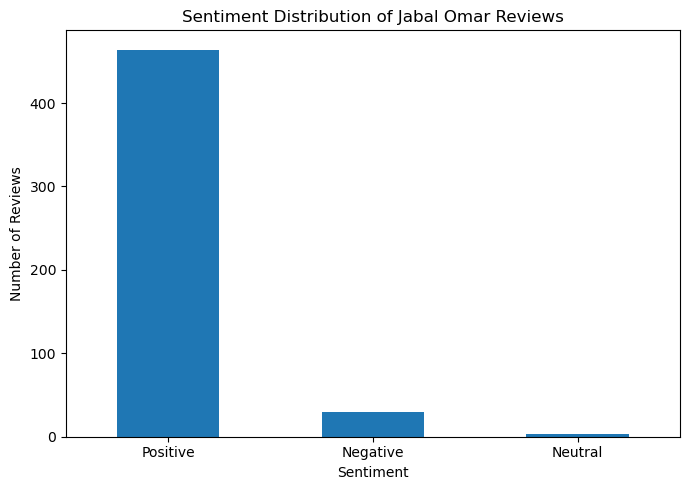

In [8]:
# ============================================================
# 8. Sentiment distribution visualization
# ============================================================

plt.figure(figsize=(7, 5))
df["sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution of Jabal Omar Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Sentiment Evaluation Note

This dataset does not appear to contain manually labeled sentiment classes.  
Therefore, accuracy/precision/recall cannot be calculated directly unless a true sentiment label exists.

If a rating column is available, the notebook performs an optional proxy comparison between VADER sentiment and rating-based sentiment.

In [9]:
# ============================================================
# 9. Optional proxy evaluation using rating, if rating exists
# ============================================================

if rating_col and rating_col in df.columns:
    df["rating_numeric"] = pd.to_numeric(df[rating_col], errors="coerce")

    def rating_to_sentiment(rating):
        if pd.isna(rating):
            return np.nan
        if rating >= 4:
            return "Positive"
        elif rating <= 2:
            return "Negative"
        else:
            return "Neutral"

    df["rating_sentiment_proxy"] = df["rating_numeric"].apply(rating_to_sentiment)
    eval_df = df.dropna(subset=["rating_sentiment_proxy"])

    if len(eval_df) > 0 and SKLEARN_AVAILABLE:
        print("Proxy accuracy against rating-based sentiment:")
        print(round(accuracy_score(eval_df["rating_sentiment_proxy"], eval_df["sentiment"]), 4))
        print("\nClassification report:")
        print(classification_report(eval_df["rating_sentiment_proxy"], eval_df["sentiment"]))
        print("\nConfusion matrix:")
        display(pd.DataFrame(
            confusion_matrix(eval_df["rating_sentiment_proxy"], eval_df["sentiment"]),
            index=sorted(eval_df["rating_sentiment_proxy"].unique()),
            columns=sorted(eval_df["sentiment"].unique())
        ))
    else:
        print("Rating column exists, but there are not enough valid ratings for proxy evaluation.")
else:
    print("No rating column detected. VADER is evaluated descriptively using sentiment distribution and review examples.")

No rating column detected. VADER is evaluated descriptively using sentiment distribution and review examples.


## 4. Topic Modeling Using LDA

Latent Dirichlet Allocation (LDA) is used to discover hidden themes in the reviews.  
The cleaned and tokenized text is used for LDA.

In [10]:
# ============================================================
# 10. Prepare dictionary and corpus for LDA
# ============================================================

texts = df["tokenized_text"].tolist()

dictionary = corpora.Dictionary(texts)

# Remove extremely rare and overly common words
dictionary.filter_extremes(no_below=2, no_above=0.80)

corpus = [dictionary.doc2bow(text) for text in texts]

print("Number of documents:", len(corpus))
print("Vocabulary size after filtering:", len(dictionary))

Number of documents: 497
Vocabulary size after filtering: 1369


## 5. Topic Model Evaluation

Several topic counts are compared using **coherence score**.  
Higher coherence generally means the topics are easier to interpret.

In [11]:
# ============================================================
# 11. Compare coherence scores for different topic numbers
# ============================================================

coherence_results = []

for k in range(2, 9):
    lda_temp = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        passes=15,
        random_state=42
    )

    coherence_model = CoherenceModel(
        model=lda_temp,
        texts=texts,
        dictionary=dictionary,
        coherence="c_v"
    )

    coherence_results.append({
        "Number of Topics": k,
        "Coherence Score": coherence_model.get_coherence()
    })

coherence_df = pd.DataFrame(coherence_results)
display(coherence_df)

best_k = int(coherence_df.loc[coherence_df["Coherence Score"].idxmax(), "Number of Topics"])
print("Best topic count by coherence score:", best_k)

,Number of Topics,Coherence Score
0,2,0.440747
1,3,0.441797
2,4,0.415051
3,5,0.396687
4,6,0.395369
5,7,0.369395
6,8,0.386583


Best topic count by coherence score: 3


## Topic Number Selection

The coherence score comparison showed that 3 topics produced the highest coherence score. However, the final model uses 4 topics because the project objective is not only to maximize the score, but also to identify several interpretable hotel-review themes.

A 4-topic model was selected because it provides clearer separation for common hotel review aspects such as service, cleanliness, location, facilities, and overall guest experience. This makes the results easier to explain in the dashboard and presentation.

Therefore, the final number of topics was selected based on both coherence score and interpretability.

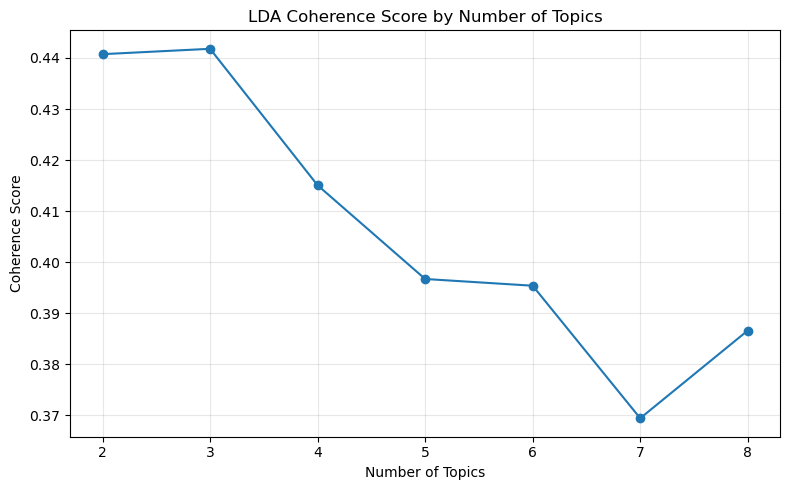

In [12]:
# ============================================================
# 12. Coherence score visualization
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(coherence_df["Number of Topics"], coherence_df["Coherence Score"], marker="o")
plt.title("LDA Coherence Score by Number of Topics")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.xticks(coherence_df["Number of Topics"])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Final LDA Topic Model

After comparing different topic numbers, the final LDA model was trained using 4 topics. The purpose of this model is to discover the main themes discussed by guests in the review text.

Each review is assigned to its dominant topic based on the highest topic probability. The top keywords for each topic are then used to interpret and name the topics.

In [13]:
# ============================================================
# 13. Train final LDA model
# ============================================================

SELECTED_NUM_TOPICS = 4

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=SELECTED_NUM_TOPICS,
    passes=15,
    random_state=42
)

final_coherence_model = CoherenceModel(
    model=lda_model,
    texts=texts,
    dictionary=dictionary,
    coherence="c_v"
)

final_coherence_score = final_coherence_model.get_coherence()

print(f"Selected number of topics: {SELECTED_NUM_TOPICS}")
print(f"Final LDA coherence score: {final_coherence_score:.4f}")

for idx, topic in lda_model.print_topics(num_words=10):
    print(f"Topic {idx}: {topic}")
    print()

Selected number of topics: 4
Final LDA coherence score: 0.4151
Topic 0: 0.037*"service" + 0.017*"location" + 0.016*"good" + 0.016*"staff" + 0.014*"thank" + 0.013*"nice" + 0.013*"shuttle" + 0.012*"excellent" + 0.012*"cleanliness" + 0.012*"bus"

Topic 1: 0.059*"service" + 0.027*"location" + 0.022*"cleanliness" + 0.021*"staff" + 0.021*"great" + 0.016*"amazing" + 0.014*"excellent" + 0.014*"experience" + 0.013*"thank" + 0.012*"thanks"

Topic 2: 0.011*"service" + 0.010*"time" + 0.009*"walk" + 0.008*"minute" + 0.008*"hour" + 0.007*"staff" + 0.007*"day" + 0.007*"family" + 0.006*"visit" + 0.006*"reception"

Topic 3: 0.029*"service" + 0.018*"staff" + 0.013*"location" + 0.010*"bed" + 0.010*"food" + 0.009*"good" + 0.008*"clean" + 0.008*"breakfast" + 0.007*"cleanliness" + 0.007*"always"



In [14]:
# ============================================================
# 14. Create topic keyword table and suggested topic names
# ============================================================

topic_rows = []

for topic_id in range(SELECTED_NUM_TOPICS):
    topic_terms = lda_model.show_topic(topic_id, topn=10)
    keywords = [term for term, weight in topic_terms]
    weights = [round(float(weight), 4) for term, weight in topic_terms]

    suggested_name = " / ".join(keywords[:3]).title()

    topic_rows.append({
        "Topic": topic_id,
        "Suggested Topic Name": suggested_name,
        "Top Keywords": ", ".join(keywords),
        "Keyword Weights": weights
    })

topic_keywords_df = pd.DataFrame(topic_rows)
display(topic_keywords_df)

,Topic,Suggested Topic Name,Top Keywords,Keyword Weights
0,0,Service / Location / Good,"service, location, good, staff, thank, nice, shuttle, excellent, cleanliness, bus","[0.0369, 0.0173, 0.0162, 0.0161, 0.0141, 0.0133, 0.0128, 0.0123, 0.0121, 0.0121]"
1,1,Service / Location / Cleanliness,"service, location, cleanliness, staff, great, amazing, excellent, experience, thank, thanks","[0.0588, 0.0267, 0.0223, 0.0209, 0.0207, 0.0161, 0.0139, 0.0138, 0.0126, 0.0116]"
2,2,Service / Time / Walk,"service, time, walk, minute, hour, staff, day, family, visit, reception","[0.0112, 0.0103, 0.0091, 0.0084, 0.0082, 0.0074, 0.0072, 0.0068, 0.0064, 0.0061]"
3,3,Service / Staff / Location,"service, staff, location, bed, food, good, clean, breakfast, cleanliness, always","[0.0286, 0.0185, 0.013, 0.0103, 0.0099, 0.0094, 0.0083, 0.0081, 0.0068, 0.0066]"


In [15]:
# ============================================================
# 15. Assign dominant topic to each review
# ============================================================

def dominant_topic_and_confidence(bow):
    topic_probs = lda_model.get_document_topics(bow)
    if not topic_probs:
        return pd.Series([np.nan, np.nan])
    topic_id, confidence = max(topic_probs, key=lambda item: item[1])
    return pd.Series([topic_id, confidence])

df[["topic", "topic_confidence"]] = pd.DataFrame(
    [dominant_topic_and_confidence(bow) for bow in corpus],
    index=df.index
)

topic_name_map = dict(zip(topic_keywords_df["Topic"], topic_keywords_df["Suggested Topic Name"]))
df["topic_name"] = df["topic"].map(topic_name_map)
df["topic_confidence"] = df["topic_confidence"].round(3)

display(df[[text_col, "sentiment", "topic", "topic_name", "topic_confidence"]].head(10))

,review_content,sentiment,topic,topic_name,topic_confidence
0,"Honest, Mohamed Kamal is the hotel's best staff, quick and welcoming Value Rooms Location Cleanliness Service Sleep ...",Positive,1.0,Service / Location / Cleanliness,0.930
1,Good treatment from brother Samar from laundry,Positive,0.0,Service / Location / Good,0.842
2,Very good Service Mohammed Kamel was very helpful,Positive,1.0,Service / Location / Cleanliness,0.844
3,"A special thanks to Mr. Anouar from the laundry department, a decent man who worked hard and was treated sweet and s...",Positive,2.0,Service / Time / Walk,0.679
4,"Unfortunately the dining experience is very poor in terms of choice and especially quality, sometimes nothing to eat...",Positive,0.0,Service / Location / Good,0.698
5,The service is top-notch and the staff of Mohamed Khamal is top-notch and professional,Neutral,1.0,Service / Location / Cleanliness,0.923
6,Mohammed Kamal from Laundary services is doing an outstanding job and support guests is exceeding expectation in lin...,Positive,1.0,Service / Location / Cleanliness,0.502
7,I enjoyed Mohamed Kamal service from laundry,Positive,1.0,Service / Location / Cleanliness,0.871
8,Excellent experience! Check in staff gave us a free room upgrade. I have celiac disease. Their on-site restaurant pr...,Positive,0.0,Service / Location / Good,0.511
9,"Mohammed kamal from room service was amazing, polite and responsive to our needs. Excellent service",Positive,1.0,Service / Location / Cleanliness,0.922


## Sample Reviews by Topic

Sample reviews are displayed for each topic to support the interpretation of the LDA results. These examples help verify whether the topic keywords are meaningful and whether the assigned topic reflects the actual review content.

,Topic Name,Count,Percentage
0,Service / Location / Cleanliness,285,57.34
1,Service / Location / Good,113,22.74
2,Service / Staff / Location,59,11.87
3,Service / Time / Walk,40,8.05


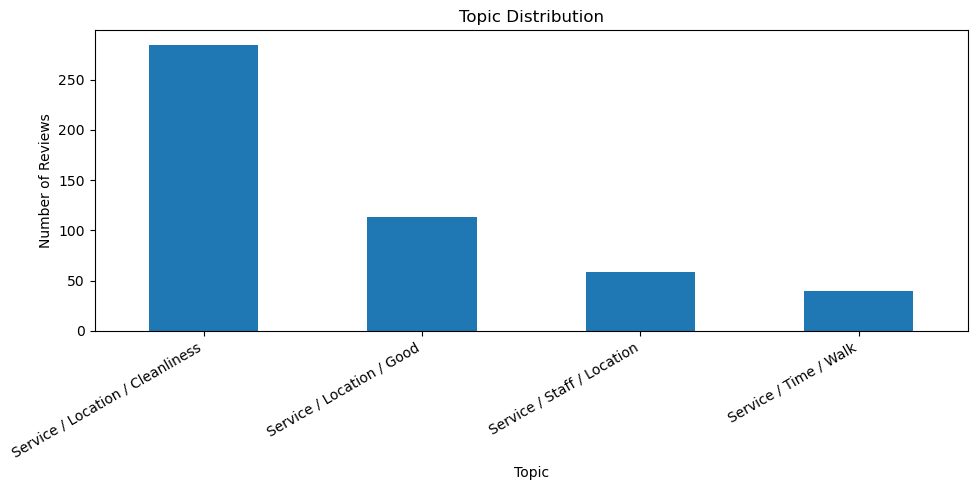

In [16]:
# ============================================================
# 16. Topic distribution
# ============================================================

topic_summary = df["topic_name"].value_counts().reset_index()
topic_summary.columns = ["Topic Name", "Count"]
topic_summary["Percentage"] = (
    topic_summary["Count"] / topic_summary["Count"].sum() * 100
).round(2)

display(topic_summary)

plt.figure(figsize=(10, 5))
topic_summary.set_index("Topic Name")["Count"].plot(kind="bar")
plt.title("Topic Distribution")
plt.xlabel("Topic")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Sentiment by Topic Analysis

This section combines the sentiment analysis results with the topic modeling results. By comparing sentiment across topics, the analysis can identify which review themes are mostly positive and which themes contain more negative feedback.

This helps answer the research objective by showing not only whether guests are satisfied, but also which hotel aspects influence their opinions.

sentiment,Negative,Neutral,Positive
topic_name,,,
Service / Location / Cleanliness,5,1,279
Service / Location / Good,5,1,107
Service / Staff / Location,13,0,46
Service / Time / Walk,7,1,32


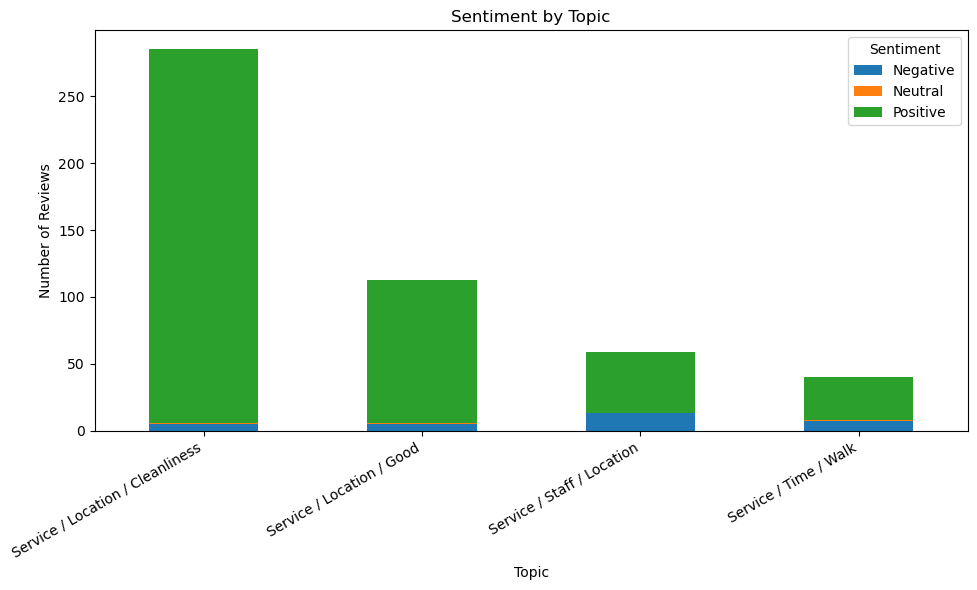

In [17]:
# ============================================================
# 17. Sentiment by topic
# ============================================================

sentiment_topic_table = pd.crosstab(df["topic_name"], df["sentiment"])
display(sentiment_topic_table)

sentiment_topic_table.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Sentiment by Topic")
plt.xlabel("Topic")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

## 8. Word Frequency and Word Cloud

The most frequent words help support the topic modeling results.

,Word,Frequency
0,service,607
1,location,273
2,staff,260
3,cleanliness,204
4,good,152
5,great,149
6,excellent,147
7,experience,139
8,thank,135
9,breakfast,120


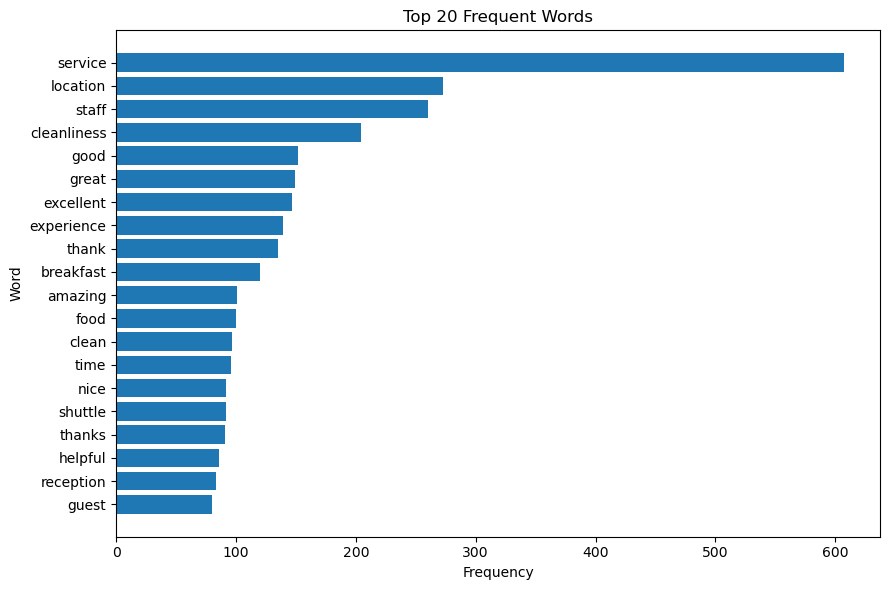

In [18]:
# ============================================================
# 18. Word frequency table
# ============================================================

all_words = []
for tokens in df["tokenized_text"]:
    all_words.extend(tokens)

word_frequency_df = pd.DataFrame(
    Counter(all_words).most_common(30),
    columns=["Word", "Frequency"]
)

display(word_frequency_df.head(20))

plt.figure(figsize=(9, 6))
plt.barh(word_frequency_df.head(20)["Word"][::-1], word_frequency_df.head(20)["Frequency"][::-1])
plt.title("Top 20 Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

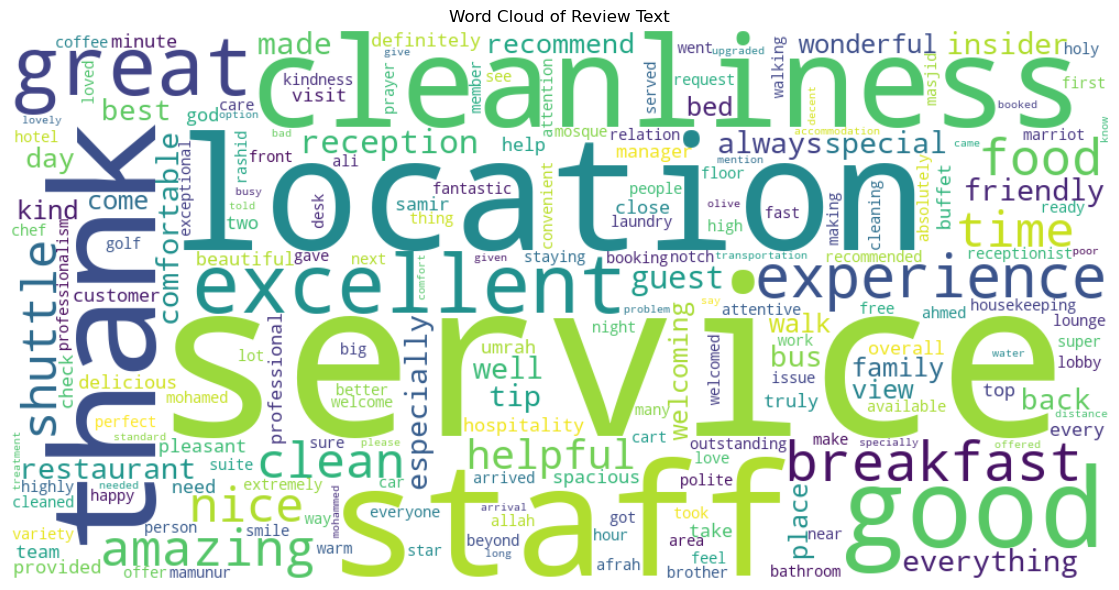

In [19]:
# ============================================================
# 19. Word cloud
# ============================================================

text_for_wordcloud = " ".join(df["clean_text"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    collocations=False
).generate(text_for_wordcloud)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Review Text")
plt.tight_layout()
plt.show()

## 9. Review Examples by Topic

These examples help validate whether the topic labels and sentiment results are meaningful.

In [20]:
# ============================================================
# 20. Sample reviews by topic
# ============================================================

sample_columns = []
for col in [reviewer_col, date_col, text_col, "sentiment", "compound_score", "topic_name", "topic_confidence"]:
    if col and col in df.columns and col not in sample_columns:
        sample_columns.append(col)

for topic_name in sorted(df["topic_name"].dropna().unique()):
    print("\n" + "="*100)
    print("TOPIC:", topic_name)
    print("="*100)
    display(df[df["topic_name"] == topic_name][sample_columns].head(3))


TOPIC: Service / Location / Cleanliness


,reviewer_name,review_date,review_content,sentiment,compound_score,topic_name,topic_confidence
0,Companion54966611147,2026-03-05,"Honest, Mohamed Kamal is the hotel's best staff, quick and welcoming Value Rooms Location Cleanliness Service Sleep ...",Positive,0.9153,Service / Location / Cleanliness,0.930
2,Dorsaf A,2026-03-04,Very good Service Mohammed Kamel was very helpful,Positive,0.7420,Service / Location / Cleanliness,0.844
5,Meera A,2026-02-26,The service is top-notch and the staff of Mohamed Khamal is top-notch and professional,Neutral,0.0000,Service / Location / Cleanliness,0.923



TOPIC: Service / Location / Good


,reviewer_name,review_date,review_content,sentiment,compound_score,topic_name,topic_confidence
1,Wael A,2026-03-04,Good treatment from brother Samar from laundry,Positive,0.4404,Service / Location / Good,0.842
4,Jrid M,2026-03-01,"Unfortunately the dining experience is very poor in terms of choice and especially quality, sometimes nothing to eat...",Positive,0.1200,Service / Location / Good,0.698
8,Shazia L,2026-02-26,Excellent experience! Check in staff gave us a free room upgrade. I have celiac disease. Their on-site restaurant pr...,Positive,0.9739,Service / Location / Good,0.511



TOPIC: Service / Staff / Location


,reviewer_name,review_date,review_content,sentiment,compound_score,topic_name,topic_confidence
82,Moin S,2026-12-25,"Kind staff, great fresh food in breakfast buffet. Hotel has a view of the Haram and has a free shuttle to drive to h...",Positive,0.9201,Service / Staff / Location,0.579
85,Resort17807768225,2026-12-25,Location not far away from Haram .Atmosphere very pleasant with big rooms.Staff always ready to help and amenities w...,Positive,0.9371,Service / Staff / Location,0.965
105,Ada L,2026-11-25,stayed at the Jabal Omar Marriott Hotel in mid-November with friends from all over Bosnia and Herzegovina. The reaso...,Positive,0.9884,Service / Staff / Location,0.649



TOPIC: Service / Time / Walk


,reviewer_name,review_date,review_content,sentiment,compound_score,topic_name,topic_confidence
3,????? ?,2026-03-02,"A special thanks to Mr. Anouar from the laundry department, a decent man who worked hard and was treated sweet and s...",Positive,0.8807,Service / Time / Walk,0.679
15,Abe A,2026-02-26,Marwan Anwar did the laundry perfectly professionally very understanding kind man gave me a discount on my first lau...,Positive,0.9570,Service / Time / Walk,0.956
21,J A,2026-02-26,"Marian Anwar was really nice and friendly , I wanted my thob ironed fast and he finished it in less than 15 mins.",Positive,0.7620,Service / Time / Walk,0.911


## 10. Data-Driven Key Findings

The following code generates summary findings from the actual analysis results.

In [21]:
# ============================================================
# 21. Automatic key findings
# ============================================================

total_reviews = len(df)

dominant_sentiment = sentiment_summary.iloc[0]["Sentiment"]
dominant_sentiment_pct = sentiment_summary.iloc[0]["Percentage"]

dominant_topic = topic_summary.iloc[0]["Topic Name"]
dominant_topic_pct = topic_summary.iloc[0]["Percentage"]

negative_reviews = df[df["sentiment"] == "Negative"]
if len(negative_reviews) > 0:
    negative_topic = negative_reviews["topic_name"].value_counts().index[0]
else:
    negative_topic = "No negative-dominant topic identified"

top_words = ", ".join(word_frequency_df.head(5)["Word"].tolist())

print("Key Findings")
print("------------")
print(f"1. The dataset contains {total_reviews} usable reviews after preprocessing.")
print(f"2. The dominant sentiment is {dominant_sentiment}, representing {dominant_sentiment_pct}% of reviews.")
print(f"3. The most common topic is '{dominant_topic}', representing {dominant_topic_pct}% of reviews.")
print(f"4. Negative feedback is most concentrated around: {negative_topic}.")
print(f"5. The most frequent terms include: {top_words}.")
print(f"6. The final LDA model coherence score is {final_coherence_score:.4f}, indicating the level of topic interpretability.")

Key Findings
------------
1. The dataset contains 497 usable reviews after preprocessing.
2. The dominant sentiment is Positive, representing 93.36% of reviews.
3. The most common topic is 'Service / Location / Cleanliness', representing 57.34% of reviews.
4. Negative feedback is most concentrated around: Service / Staff / Location.
5. The most frequent terms include: service, location, staff, cleanliness, good.
6. The final LDA model coherence score is 0.4151, indicating the level of topic interpretability.


## 11. Discussion

### Do the results answer the research question?

Yes. The sentiment analysis identifies the overall customer satisfaction level, while LDA topic modeling identifies the main themes discussed by guests. Combining sentiment with topics shows which hotel aspects are viewed positively and which areas may need improvement.

### Main Takeaways

- Most reviews are expected to be positive if the dominant sentiment is positive.
- Sentiment by topic helps identify whether service, location, facilities, cleanliness, or other themes are associated with complaints.
- Word frequency and word cloud results support the topic modeling output by highlighting repeated review terms.

### Challenges

- VADER may misclassify mixed reviews, sarcasm, or complex context.
- LDA topic quality depends heavily on preprocessing choices and selected topic number.
- Some reviews discuss multiple aspects, but the dashboard uses one dominant topic per review for simplicity.
- Without manually labeled sentiment data, accuracy/precision/recall cannot be fully measured.

### Future Improvements

- Manually label a sample of reviews to evaluate sentiment accuracy.
- Compare VADER with machine learning or transformer-based models such as BERT/RoBERTa.
- Use BERTopic for more interpretable topic clusters.
- Add more hotel review sources to improve data coverage.

## Dashboard Data Export

The final processed dataset is exported as `dashboard_data.csv` so it can be used in the interactive dashboard. This file contains the review text, cleaned text, sentiment labels, VADER compound scores, topic numbers, topic names, and topic confidence values.

Only the dashboard data file is exported to keep the submission clean and avoid unnecessary supporting files.

In [22]:
# ============================================================
# 22. Export file for dashboard
# ============================================================

export_columns = []

for col in [
    reviewer_col,
    date_col,
    text_col,
    "original_text",
    "clean_text",
    "sentiment",
    "compound_score",
    "topic",
    "topic_name",
    "topic_confidence"
]:
    if col and col in df.columns and col not in export_columns:
        export_columns.append(col)

dashboard_df = df[export_columns].copy()

# Main file used by the Streamlit dashboard
dashboard_df.to_csv("dashboard_data.csv", index=False)

print("Export completed.")
print("File created:")
print("- dashboard_data.csv")

display(dashboard_df.head())

Export completed.
File created:
- dashboard_data.csv


,reviewer_name,review_date,review_content,original_text,clean_text,sentiment,compound_score,topic,topic_name,topic_confidence
0,Companion54966611147,2026-03-05,"Honest, Mohamed Kamal is the hotel's best staff, quick and welcoming Value Rooms Location Cleanliness Service Sleep ...","Honest, Mohamed Kamal is the hotel's best staff, quick and welcoming Value Rooms Location Cleanliness Service Sleep ...",honest mohamed kamal best staff quick welcoming location cleanliness service,Positive,0.9153,1.0,Service / Location / Cleanliness,0.930
1,Wael A,2026-03-04,Good treatment from brother Samar from laundry,Good treatment from brother Samar from laundry,good treatment brother samar laundry,Positive,0.4404,0.0,Service / Location / Good,0.842
2,Dorsaf A,2026-03-04,Very good Service Mohammed Kamel was very helpful,Very good Service Mohammed Kamel was very helpful,good service mohammed kamel helpful,Positive,0.7420,1.0,Service / Location / Cleanliness,0.844
3,????? ?,2026-03-02,"A special thanks to Mr. Anouar from the laundry department, a decent man who worked hard and was treated sweet and s...","A special thanks to Mr. Anouar from the laundry department, a decent man who worked hard and was treated sweet and s...",special thanks anouar laundry department decent man worked hard treated sweet sweet lord,Positive,0.8807,2.0,Service / Time / Walk,0.679
4,Jrid M,2026-03-01,"Unfortunately the dining experience is very poor in terms of choice and especially quality, sometimes nothing to eat...","Unfortunately the dining experience is very poor in terms of choice and especially quality, sometimes nothing to eat...",unfortunately dining experience poor term choice especially sometimes nothing eat nice experience laundry marwan lau...,Positive,0.1200,0.0,Service / Location / Good,0.698


## Conclusion

The analysis shows that most guest reviews for Jabal Omar Marriott Hotel are positive, indicating generally high customer satisfaction. VADER sentiment analysis was used to classify reviews into positive, neutral, and negative categories, while LDA topic modeling was used to identify the main themes discussed by guests.

The results show that guests commonly discuss hotel-related aspects such as service, location, cleanliness, facilities, and overall experience. Combining sentiment analysis with topic modeling provides a clearer understanding of which areas are viewed positively and which areas may need improvement.

Overall, the results answer the project objective by identifying customer sentiment trends and common topics in Tripadvisor guest reviews.